# Tutorial 4 — Response times and component lifetimes

## 1. Problem / context

Two kinds of continuous measurement appear constantly in software and hardware:

- API **response times** (ms), often modelled as approximately normal after a log-transform, or as a first approximation by a normal on the raw scale if the histogram is not too skewed.
- Component **lifetimes** (h), often modelled as exponential when a constant hazard is plausible.

We will compute probabilities with SciPy. We will not integrate densities by hand.

## 2. Core theory

For a continuous $X$, $P(X=x)=0$. Probability is **area** under the PDF $f_X$. The CDF is $F_X(x)=P(X\le x)$.

**Uniform**($a,b$): constant density on an interval.

**Normal**: $X\sim N(\mu,\sigma^2)$. SciPy takes `loc=mu` and `scale=sigma` (the standard deviation). A $z$-score is $z=(x-\mu)/\sigma$.

**Exponential** with **rate** $\lambda$: $E[T]=1/\lambda$. SciPy uses `expon(scale=1/rate)`. Never name the Python variable `lambda`.

A **QQ-plot** compares sample quantiles with model quantiles. It is a diagnostic, not a proof.

## 3. From mathematics to Python

| Need | Mathematics | SciPy |
| --- | --- | --- |
| $P(X\le x)$ | $F_X(x)$ | `dist.cdf(x)` |
| $P(X>x)$ | $1-F_X(x)$ | `dist.sf(x)` |
| Percentile | $F_X^{-1}(p)$ | `dist.ppf(p)` |
| Simulate | — | `dist.rvs(size=..., random_state=42)` |

## 4. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm, expon, probplot

candidates = [Path("data"), Path("../data")]
DATA = next(p for p in candidates if p.exists())

times = pd.read_csv(DATA / "response_times.csv")["server_a_ms"]
mu_hat, sigma_hat = times.mean(), times.std(ddof=1)
model = norm(loc=mu_hat, scale=sigma_hat)
print(f"N({mu_hat:.2f}, {sigma_hat**2:.2f})  [variance shown; SciPy scale is sigma={sigma_hat:.2f}]")
print("P(X > 140 ms) =", model.sf(140))
print("95th percentile (ms) =", model.ppf(0.95))


N(118.53, 196.89)  [variance shown; SciPy scale is sigma=14.03]
P(X > 140 ms) = 0.06303107200855577
95th percentile (ms) = 141.61418379252802


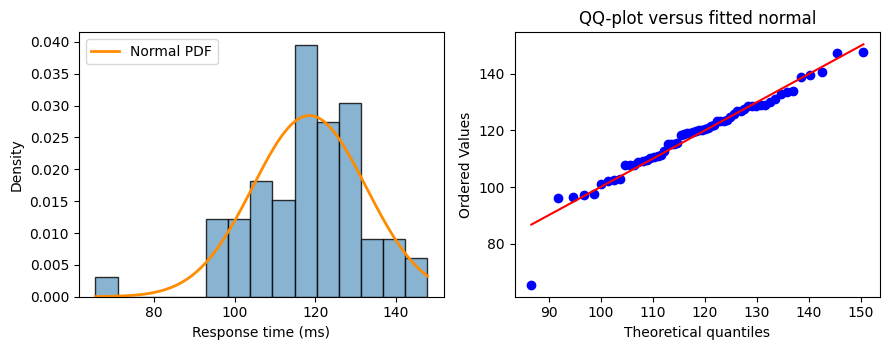

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
xs = np.linspace(times.min(), times.max(), 200)
axes[0].hist(times, bins=15, density=True, edgecolor="black", color="#6CA2C6", alpha=0.8)
axes[0].plot(xs, model.pdf(xs), color="#FF8C00", lw=2, label="Normal PDF")
axes[0].set_xlabel("Response time (ms)")
axes[0].set_ylabel("Density")
axes[0].legend()
probplot(times, dist=model, plot=axes[1])
axes[1].set_title("QQ-plot versus fitted normal")
plt.tight_layout()
plt.show()


Exponential lifetimes:


In [3]:
life = pd.read_csv(DATA / "component_lifetimes.csv")["lifetime_h"]
mean_life = life.mean()
rate = 1 / mean_life
wait = expon(scale=1 / rate)
print(f"rate = {rate:.4f} per hour, mean = {mean_life:.1f} h")
print("P(T > 600 h) =", wait.sf(600))
print("P(T < 100 h) =", wait.cdf(100))


rate = 0.0030 per hour, mean = 330.1 h
P(T > 600 h) = 0.16244201172143513
P(T < 100 h) = 0.2613312494465135


## 5. Interpretation

The normal model on response times is a **working approximation** for computing tail probabilities and percentiles. The QQ-plot tells you whether that approximation is crude. Lifetimes use a rate: 400 h mean lifetime means `rate = 1/400` per hour. The Poisson process story behind exponential waiting times belongs to SMP1; here we only use the distribution.

## 6. Common mistakes / things to notice

- Passing variance to `norm(scale=...)`. Scale is $\sigma$, not $\sigma^2$.
- Writing $X\sim N(\mu,\sigma)$ in mathematics. In this course: $N(\mu,\sigma^2)$.
- `expon(scale=rate)` — that is the wrong parameterisation.
- Integrating $f(x)$ by hand in STA1. Use `cdf` / `sf`.

## 7. Short worked example

Noise on a voltage measurement is modelled as $N(5.00, 0.02^2)$ V. Find $P(4.96 \le X \le 5.04)$ and the 99th percentile.


In [4]:
volt = norm(loc=5.00, scale=0.02)
print(volt.cdf(5.04) - volt.cdf(4.96))
print(volt.ppf(0.99))


0.9544997361036418
5.0465269574808165


**Conclusion in one sentence:** Response-time percentiles and lifetime tail probabilities are computed from PDF/CDF tools in SciPy; the modelling choice (normal versus exponential) must match the physical story, not the first function that runs without error.
